In [4]:
import cv2
import numpy as np
from pathlib import Path

img1 = cv2.imread('./img1.jpg', cv2.IMREAD_GRAYSCALE)

template = img1[100:300, 100:300]

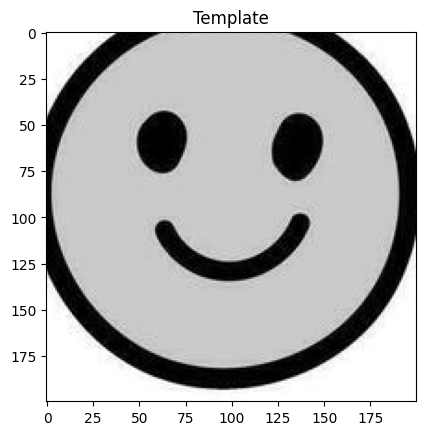

In [6]:
import matplotlib.pyplot as plt


plt.imshow(template, cmap='gray')
plt.title('Template')
plt.show()

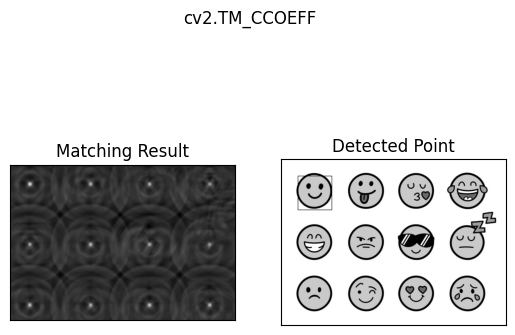

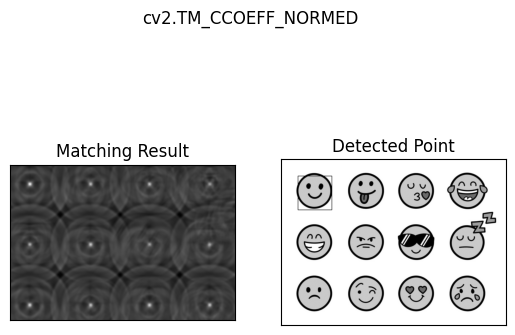

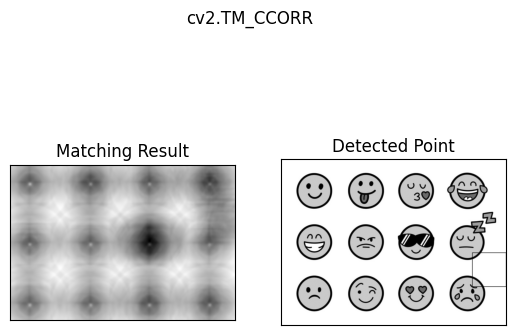

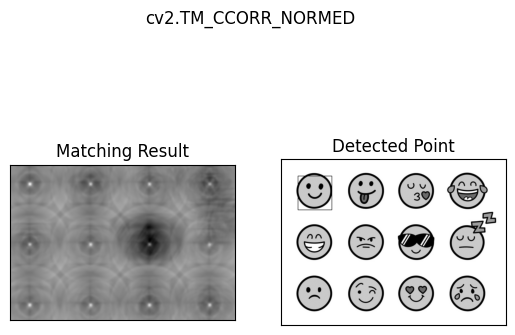

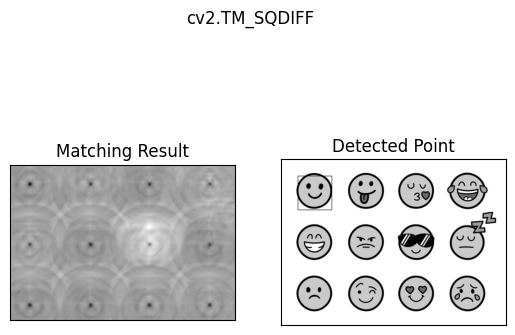

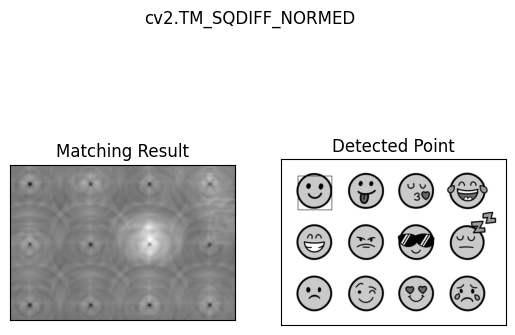

In [7]:
w, h = template.shape[::-1]
methods = ['cv2.TM_CCOEFF',
           'cv2.TM_CCOEFF_NORMED',
           'cv2.TM_CCORR',
           'cv2.TM_CCORR_NORMED',
           'cv2.TM_SQDIFF',
           'cv2.TM_SQDIFF_NORMED']

for meth in methods:
    input = img1.copy()
    method = eval(meth)
    res = cv2.matchTemplate(img1, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv2.rectangle(input, top_left, bottom_right, 0, 2)
    plt.figure()
    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(input, cmap='gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)
plt.show()

In [8]:
img1 = cv2.imread('./img4.jpg', cv2.IMREAD_GRAYSCALE)

dst = cv2.cornerHarris(img1, 2, 3, 0.06)
dst = cv2.dilate(dst, None)
res1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
res1[dst>0.1*dst.max()] = [0, 0, 255]

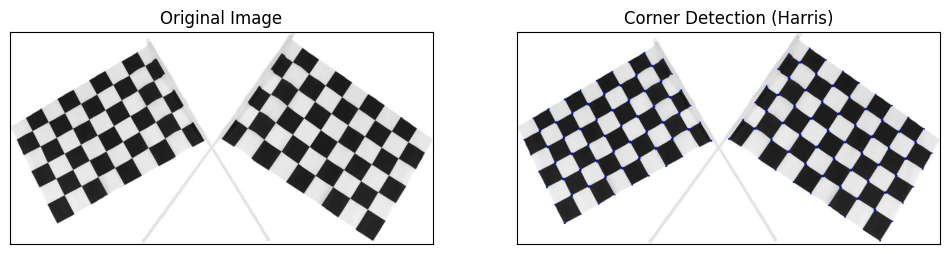

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res1)
plt.title('Corner Detection (Harris)'), plt.xticks([]), plt.yticks([])
plt.show()

In [10]:
img1 = cv2.imread('./img4.jpg', cv2.IMREAD_GRAYSCALE)

dst = cv2.cornerHarris(img1, 5, 3, 0.06)
dst = cv2.dilate(dst, None)
res1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
res1[dst>0.1*dst.max()] = [0, 0, 255]

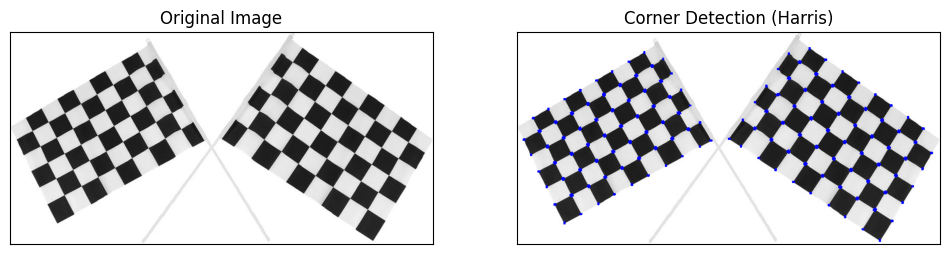

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res1)
plt.title('Corner Detection (Harris)'), plt.xticks([]), plt.yticks([])
plt.show()

In [17]:
img1 = cv2.imread('./img5.jpg', cv2.IMREAD_GRAYSCALE)
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(img1, 1.1, 3)

res1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in faces:
    cv2.rectangle(res1, (x, y), (x+w, y+h), (255, 0, 0), 2)

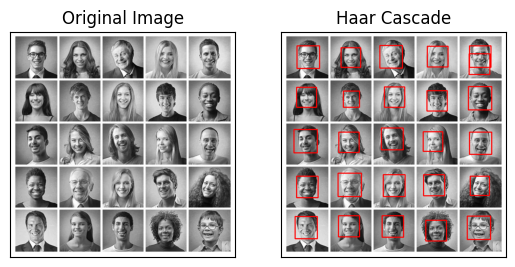

In [18]:
plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res1)
plt.title('Haar Cascade'), plt.xticks([]), plt.yticks([])
plt.show()

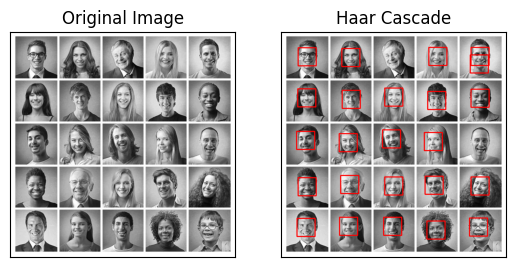

In [20]:
img1 = cv2.imread('./img5.jpg', cv2.IMREAD_GRAYSCALE)
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(img1, 2, 3)

res1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in faces:
    cv2.rectangle(res1, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res1)
plt.title('Haar Cascade'), plt.xticks([]), plt.yticks([])
plt.show()

In [22]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
(hog_peoples, weights) = hog.detectMultiScale(img1, winStride=(8, 8), padding=(32, 32), scale=1.05)

lbp_cascade = cv2.CascadeClassifier('lbpcascade_frontalface_improved.xml')
lbp_faces = lbp_cascade.detectMultiScale(img1, 1.5, 1)

res1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in hog_peoples:
    cv2.rectangle(res1, (x, y), (x + w, y + h), (255, 0, 0), 2)

res2 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in lbp_faces:
    cv2.rectangle(res2, (x, y), (x + w, y + h), (255, 0, 0), 2)

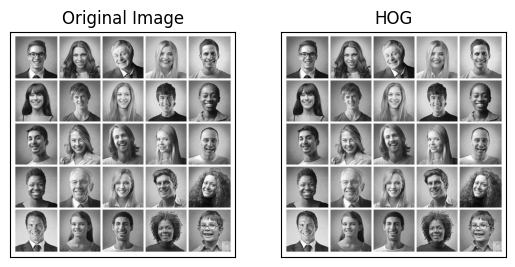

In [24]:
plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res1)
plt.title('HOG'), plt.xticks([]), plt.yticks([])
plt.show()

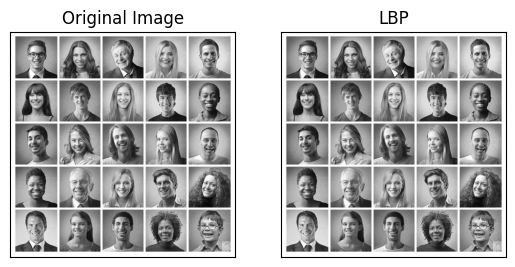

In [25]:
plt.subplot(121), plt.imshow(img1, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(res1)
plt.title('LBP'), plt.xticks([]), plt.yticks([])
plt.show()